# 09 - Model Statistics & Evaluation

**Comprehensive evaluation of all trained models.**

This notebook:
1. Loads evaluation results from `results/` folder
2. Computes metrics: ROC-AUC, Accuracy, Precision, Recall, F1-Score
3. Creates visualizations comparing model performance
4. Generates summary tables across all 12 toxicity endpoints

In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RESULTS_DIR = '../results/baseline_models'
TOXICITY_ENDPOINTS = ['NR-AhR', 'NR-AR', 'NR-AR-LBD', 'NR-Aromatase',
                      'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
                      'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
MODEL_TYPES = ['KNN', 'NN', 'RF', 'SVM', 'XGBoost']


print("✓ Setup complete")

✓ Setup complete


In [2]:
# ============================================================================
# LOAD RESULTS
# ============================================================================
def load_model_results(toxicity, model_type):
    """Load results JSON for a specific model and endpoint."""
    path = os.path.join(RESULTS_DIR, toxicity, f'{model_type}_results.json')
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return None

# Collect all results
all_results = []
for endpoint in TOXICITY_ENDPOINTS:
    for model in MODEL_TYPES:
        res = load_model_results(endpoint, model)
        if res and 'test_results' in res:
            all_results.append({
                'Endpoint': endpoint,
                'Model': model,
                'ROC_AUC': res['test_results'].get('auc', 0),
                'Accuracy': res['test_results'].get('accuracy', 0),
                'Precision': res['test_results'].get('precision', 0),
                'Recall': res['test_results'].get('recall', 0),
                'F1': res['test_results'].get('f1', 0)
            })

results_df = pd.DataFrame(all_results)
print(f"Loaded {len(results_df)} results")

Loaded 41 results


In [3]:
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
if len(results_df) > 0:
    print("\n" + "="*70)
    print("AVERAGE PERFORMANCE BY MODEL (across all endpoints)")
    print("="*70)
    
    summary = results_df.groupby('Model')[['ROC_AUC', 'Accuracy', 'F1']].mean()
    summary = summary.round(4)
    print(summary)
    
    print("\n" + "="*70)
    print("BEST MODEL PER ENDPOINT (by ROC-AUC)")
    print("="*70)
    
    best_per_endpoint = results_df.loc[results_df.groupby('Endpoint')['ROC_AUC'].idxmax()]
    print(best_per_endpoint[['Endpoint', 'Model', 'ROC_AUC']].to_string(index=False))
else:
    print("⚠️ No results found. Train models first.")


AVERAGE PERFORMANCE BY MODEL (across all endpoints)
         ROC_AUC  Accuracy      F1
Model                             
KNN       0.6859    0.9086  0.1915
NN        0.6799    0.8922  0.3154
RF        0.7407    0.9031  0.1564
SVM       0.7423    0.9050  0.1722
XGBoost   0.7278    0.9082  0.2600

BEST MODEL PER ENDPOINT (by ROC-AUC)
     Endpoint   Model  ROC_AUC
        NR-AR XGBoost 0.723300
    NR-AR-LBD     SVM 0.755401
       NR-AhR     SVM 0.777978
 NR-Aromatase     SVM 0.748527
        NR-ER      RF 0.652074
    NR-ER-LBD      RF 0.786316
NR-PPAR-gamma     SVM 0.809603
       SR-ARE     SVM 0.763282
     SR-ATAD5     KNN 0.664552


## Visualizations

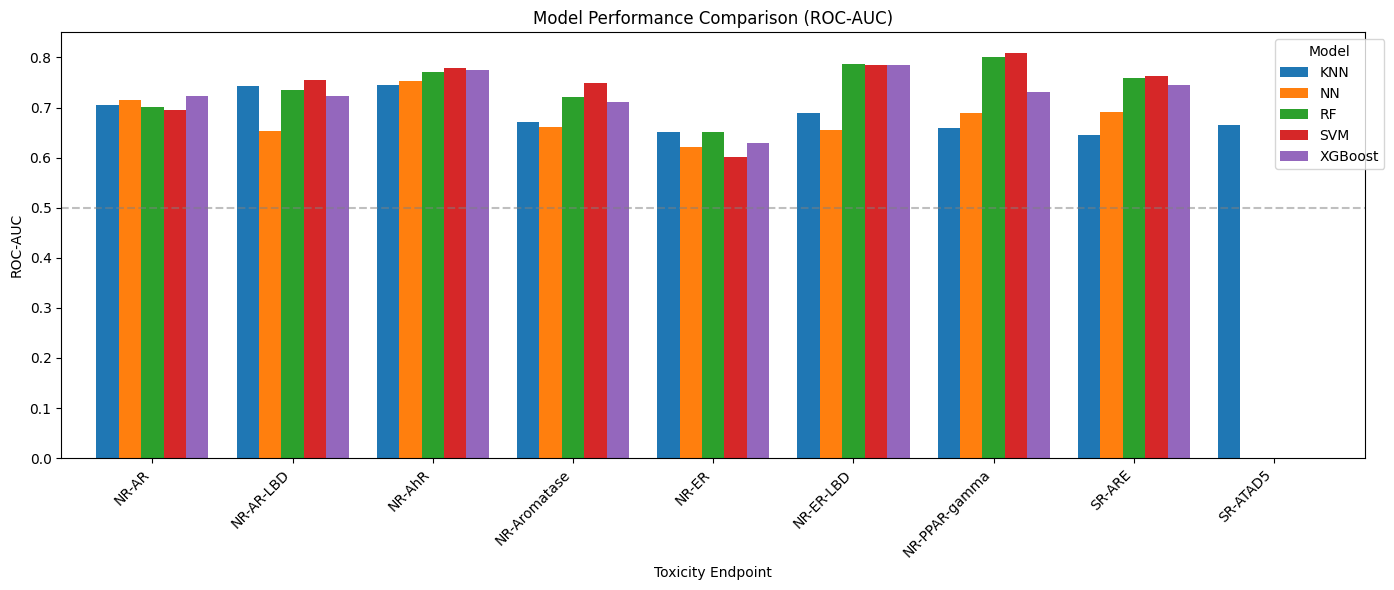

In [4]:
# ============================================================================
# ROC-AUC BAR CHART
# ============================================================================
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    pivot_df = results_df.pivot(index='Endpoint', columns='Model', values='ROC_AUC')
    pivot_df.plot(kind='bar', ax=ax, width=0.8)
    
    ax.set_xlabel('Toxicity Endpoint')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('Model Performance Comparison (ROC-AUC)')
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No data to visualize")

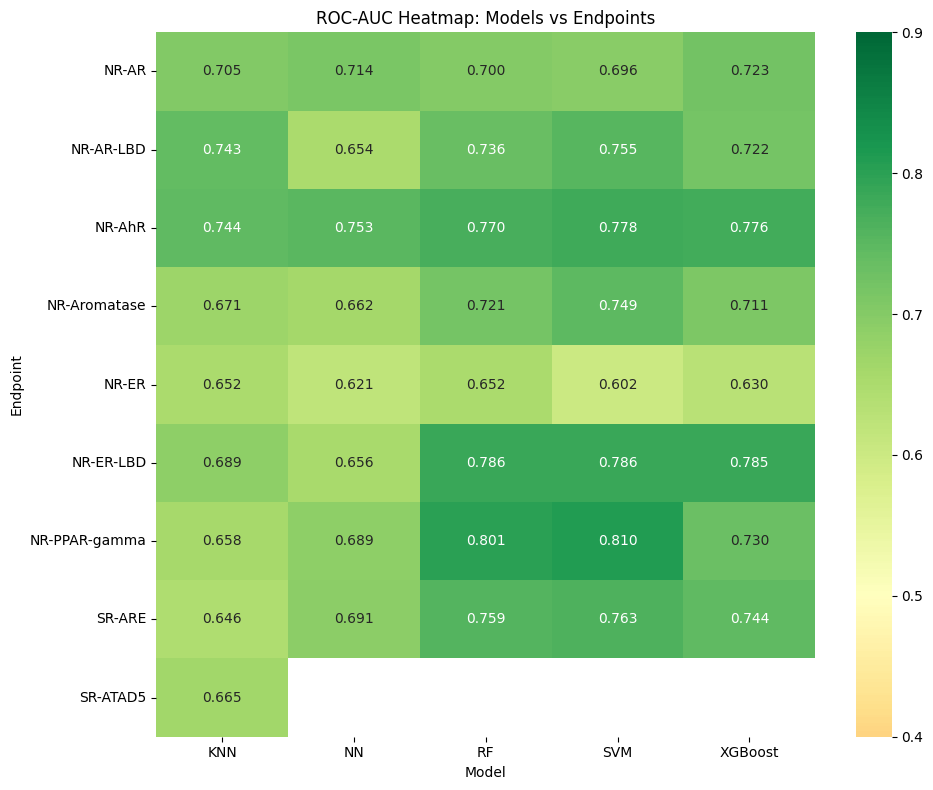


✓ Statistics complete!


In [5]:
# ============================================================================
# HEATMAP
# ============================================================================
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    pivot_df = results_df.pivot(index='Endpoint', columns='Model', values='ROC_AUC')
    
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0.5, vmin=0.4, vmax=0.9, ax=ax)
    
    ax.set_title('ROC-AUC Heatmap: Models vs Endpoints')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Statistics complete!")